# Training the Weight Autoencoder

We train a transformer VAE on ResNet-20 weight chunks with no bottleneck (`r = 1`) and KL
disabled (`beta = 0`), then check that the decoded weights still produce a working
classifier.

Compression and KL get turned on separately in the next stage, one at a time, so a failure
can always be traced to a single change.

Latent analysis and reconstruction helpers live in `latent_analysis.py`, `reconstruction.py`
and `cifar_eval_data.py`.

In [1]:
import os
import torch
import warnings
import chunking as C
from tqdm import tqdm
from pathlib import Path
from torch import nn, optim
from resnet20 import resnet20
import torch.nn.functional as F
import json, random, numpy as np
from torchvision import transforms
from torch.utils.data import DataLoader
from torchvision.datasets import CIFAR100
from transformer_vae import TVAE, vae_loss
from torch.utils.data import DataLoader, Dataset
from constants import SEED, device, TOKENS_PER_SEQ, IMG_PATH
from dataset import ResZoo, summon_res_zoo
warnings.filterwarnings("ignore")

## Load the data and data loaders

`train` is experts 0 to 2, `validation` is expert 3, `test` is expert 4 and stays
untouched until the end. `merge` holds the five final checkpoints, kept out of VAE
training so the encoder cannot have memorised the weights we later merge.

In [2]:
zoo_dir = './zoo_chunks'
training_set, validation_set, test_set, merge_set = summon_res_zoo('./zoo_chunks')
train_dataset = ResZoo(root_dir=zoo_dir, model_ids=training_set)
validation_dataset = ResZoo(root_dir=zoo_dir, model_ids=validation_set)
test_dataset = ResZoo(root_dir=zoo_dir, model_ids=test_set)
merge_dataset = ResZoo(root_dir=zoo_dir, model_ids=merge_set)

backbone_dataset = ResZoo(root_dir='./zoo_reference', model_ids=['backbone_a',])

print(f'train {len(training_set)}  val {len(validation_set)}  ', f'test {len(test_set)}  merge {len(merge_set)}')

train 27  val 9   test 10  merge 5


In [3]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
validation_loader = DataLoader(validation_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
merge_loader = DataLoader(merge_dataset, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)

## Train the TVAE 
### STAGE A: BETA = 0

`latent_dim = 144` gives `r = 1`, and `BETA = 0.0` leaves it a plain autoencoder. The
point is to give the model every advantage: if reconstruction still breaks the ResNet,
the fault is in the plumbing rather than in compression.

Worth watching the train/val gap. Our 27 training checkpoints come from only three
fine-tuning trajectories, so the effective dataset is smaller than the sequence count
suggests.

In [4]:
tvae_model = TVAE(input_dim=144, model_dim=256, latent_dim=144).to(device)
tvae_model_path = './res_models/tvae_r1.pt'
trained = False
if os.path.exists(tvae_model_path):
    check_point = torch.load(tvae_model_path, weights_only=True)
    tvae_model.load_state_dict(check_point['state_dict'])
    trained = True

In [7]:
EPOCHS = 200
BETA = 0.0            

In [5]:
@torch.no_grad()
def eval_recon(model, loader, beta=0.0):
    '''eval mode makes reparameterize return mu, so reconstruction is deterministic'''
    model.eval()
    total, n = 0.0, 0
    for batch in loader:
        chunks = batch['chunks'].to(device, non_blocking=True)
        mask = batch['mask'].to(device, non_blocking=True)
        depth = batch['depth'].to(device, non_blocking=True)
        stage = batch['stage'].to(device, non_blocking=True)
        xhat, mu, logvar = model(chunks, depth, stage)
        _, recon, _ = vae_loss(xhat, chunks, mu, logvar, mask, beta)
        total += recon.item(); n += 1
    return total / max(n, 1)

In [8]:
def train_tvae(model, train_loader, validation_loader, lr = 1e-4, EPOCHS = EPOCHS, BETA = BETA, output_path = './res_models/tvae_r1.pt'):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)
    best_val = float('inf')
    for epoch in range(EPOCHS):
        model.train()
        running_recon, running_kl, n = 0.0, 0.0, 0

        for batch in train_loader:
            chunks = batch['chunks'].to(device, non_blocking=True)
            mask = batch['mask'].to(device, non_blocking=True)
            depth = batch['depth'].to(device, non_blocking=True)
            stage = batch['stage'].to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            '''forward returns three things, not one'''
            xhat, mu, logvar = model(chunks, depth, stage)
            loss, recon, kl = vae_loss(xhat, chunks, mu, logvar, mask, BETA)
            loss.backward()
            '''clip so a rare outlier chunk cannot blow up a step'''
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_recon += recon.item(); running_kl += kl.item(); n += 1

        scheduler.step()

        if (epoch + 1) % 5 == 0 or epoch == 0:
            val_recon = eval_recon(model, validation_loader, BETA)
            print(f'epoch {epoch+1:3d}/{EPOCHS}  train recon {running_recon/n:.5f}  '
                f'val recon {val_recon:.5f}  kl {running_kl/n:.2f}  '
                f'lr {scheduler.get_last_lr()[0]:.2e}')

            if val_recon < best_val:
                best_val = val_recon
                torch.save({
                    'state_dict': model.state_dict(),
                    'epoch': epoch + 1,
                    'val_recon': val_recon,
                    'latent_dim': model.latent_dim,
                    'beta': BETA,
                }, output_path)

    print(f'done, best val recon {best_val:.5f}')


if not trained:
    train_tvae(tvae_model, train_loader, validation_loader, EPOCHS = EPOCHS, BETA = BETA, output_path = './res_models/tvae_r1.pt')


## Latent space analysis (BETA = 0)

t-SNE grids per depth, plus two distance metrics. `expert_separation` is the number to
trust: t-SNE exaggerates separation on few points, the ratio is computed on the raw
latents.

Reusable across beta values, just reload `tvae_model` and rerun.

In [8]:
from latent_analysis import (BACKBONE_LABEL, build_latents, plot_depth_grid, expert_separation, backbone_distance)

latents (4403, 16, 144)  labels [np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3)]  (-1 = backbone)


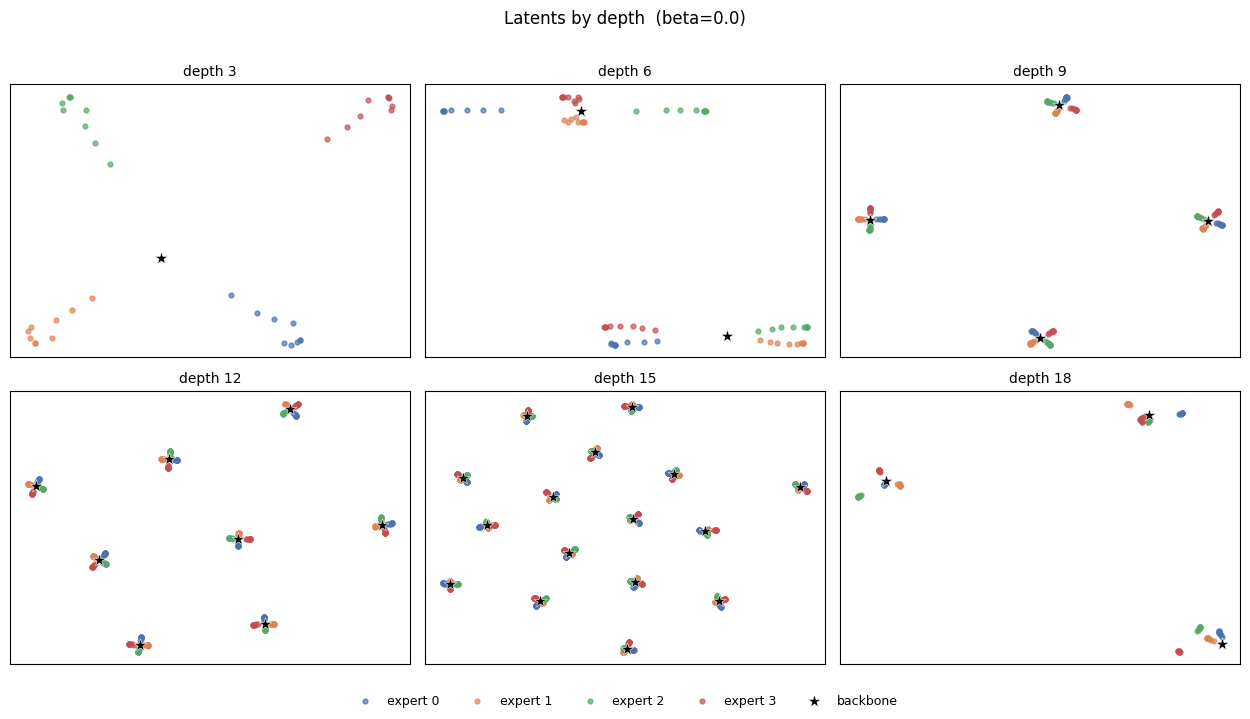


depth  3: within    2.469  between    7.701  ratio 3.120
depth  6: within   24.083  between   24.732  ratio 1.027
depth  9: within   36.646  between   37.265  ratio 1.017
depth 12: within   41.157  between   41.356  ratio 1.005
depth 15: within   43.430  between   43.559  ratio 1.003
depth 18: within   30.362  between   30.144  ratio 0.993

depth  3: backbone to experts e0=  5.310  e1=  5.102  e2=  5.663  e3=  5.810
depth  6: backbone to experts e0= 23.891  e1= 23.803  e2= 23.907  e3= 23.966
depth  9: backbone to experts e0= 36.604  e1= 36.424  e2= 36.582  e3= 36.742
depth 12: backbone to experts e0= 41.103  e1= 41.013  e2= 41.034  e3= 41.102
depth 15: backbone to experts e0= 43.378  e1= 43.361  e2= 43.365  e3= 43.399
depth 18: backbone to experts e0= 29.807  e1= 29.835  e2= 29.818  e3= 29.858


[(3,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(5.3096137),
   np.float32(5.1020985),
   np.float32(5.6629777),
   np.float32(5.809836)]),
 (6,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(23.891224),
   np.float32(23.803274),
   np.float32(23.906843),
   np.float32(23.966301)]),
 (9,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(36.604153),
   np.float32(36.42385),
   np.float32(36.58159),
   np.float32(36.74163)]),
 (12,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(41.102844),
   np.float32(41.01292),
   np.float32(41.034206),
   np.float32(41.10232)]),
 (15,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(43.377872),
   np.float32(43.36055),
   np.float32(43.365448),
   np.float32(43.39905)]),
 (18,
  [np.int64(0), np.int64(1), np.int64(2), np.int64(3)],
  [np.float32(29.80678),
   np.float32(29.835335),
   np.float32(29.817509),
   np.float32(29.858223)])]

In [9]:
BETA = 0.0

ALL_DEPTHS = list(range(3,19,3))

lat, depths, stages, splits = build_latents(
    tvae_model, zoo_dir, training_set + validation_set,
    reference_dir='./zoo_reference', reference_ids=['backbone_a'])

print(f'latents {lat.shape}  labels {sorted(set(splits))}  '
     f'({BACKBONE_LABEL} = backbone)')

plot_depth_grid(lat, depths, splits, ALL_DEPTHS, n_cols=3,
                tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'latent_grid_beta{BETA}.png'))

print()
expert_separation(lat, depths, splits, ALL_DEPTHS)
print()
backbone_distance(lat, depths, splits, ALL_DEPTHS)

## Reconstruction check (BETA = 0)

Low reconstruction loss is not enough. MSE averages over 274k weights and can look fine
while the decoder quietly smooths away the few that matter, so we load the decoded weights
back into a ResNet and measure accuracy.

BatchNorm running stats have to be reset and recalibrated first. They are properties of the
weights and data together and are invalid after any weight change.

Own-group accuracy is the number to read. `all` is dominated by the 80 classes where the
expert is already near chance, so it hides damage.

In [17]:
from reconstruction import reconstruct_model, evaluate_grouped, evaluate_reconstruction
from cifar_eval_data import load_cifar_eval

(train_dataset_cifar, test_dataset_cifar, full_test_loader, zoo_train_feed, zoo_test_feed) = load_cifar_eval('./res_data/')

In [11]:
'''expert 3 is the VAE validation model, evaluated on the CIFAR-100 test set'''
EXPERT_ID = 3
MODEL_ID = 'split3_seed1246_ep40'

ds_one = ResZoo(root_dir=zoo_dir, model_ids=[MODEL_ID])
loader_one = DataLoader(ds_one, batch_size=64, shuffle=False)

ck = torch.load('res_models/expert3_seed1246/ep040.pt', map_location='cpu')
sd_hat = reconstruct_model(tvae_model, loader_one, ds_one, ck['state_dict'])

'''recalibrate on the expert's own training subset, that is the distribution it saw'''
recal_subset = torch.utils.data.Subset(train_dataset_cifar, zoo_train_feed[EXPERT_ID])
recal_loader = DataLoader(recal_subset, batch_size=128, shuffle=True, num_workers=2)

evaluate_reconstruction(sd_hat, ck['state_dict'], EXPERT_ID, recal_loader, full_test_loader)

                   own   other     all
original         83.60    6.25   21.72
reconstructed    83.30    9.04   23.89
delta            -0.30    2.79    2.17

  worst rel err  layer3.1.conv1.weight      0.1094
  worst rel err  layer3.0.conv2.weight      0.1077
  worst rel err  layer2.1.conv2.weight      0.1032
  worst rel err  layer2.0.conv2.weight      0.1012
  worst rel err  layer3.1.conv2.weight      0.0955

  index 1249 of layer1.2.conv2: original -0.6102  reconstructed -0.5705


2.1700000000000017

## STAGE B: 
Try different BETAs = [1e-6, 1e-5, 1e-4]

In [27]:
check_point = torch.load(tvae_model_path, weights_only=True)
tvae_model.load_state_dict(check_point['state_dict'])

<All keys matched successfully>

In [28]:
BETAs = [1e-6, 1e-5, 1e-4]

for BETA in BETAs:
    print(f'BETA: {BETA}')
    tvae_model.load_state_dict(torch.load(tvae_model_path, weights_only=True)['state_dict'])
    train_tvae(tvae_model, train_loader, validation_loader, lr=1e-4, EPOCHS=50, BETA=BETA, output_path=f'./res_models/tvae_r1_beta{BETA}.pt')

BETA: 1e-06


epoch   1/50  train recon 0.00690  val recon 0.00266  kl 679.08  lr 9.99e-05
epoch   5/50  train recon 0.00107  val recon 0.00244  kl 637.75  lr 9.76e-05
epoch  10/50  train recon 0.00098  val recon 0.00251  kl 630.40  lr 9.05e-05
epoch  15/50  train recon 0.00076  val recon 0.00205  kl 628.94  lr 7.94e-05
epoch  20/50  train recon 0.00060  val recon 0.00194  kl 627.94  lr 6.55e-05
epoch  25/50  train recon 0.00056  val recon 0.00188  kl 626.29  lr 5.00e-05
epoch  30/50  train recon 0.00052  val recon 0.00183  kl 625.44  lr 3.45e-05
epoch  35/50  train recon 0.00050  val recon 0.00179  kl 625.09  lr 2.06e-05
epoch  40/50  train recon 0.00048  val recon 0.00177  kl 624.66  lr 9.55e-06
epoch  45/50  train recon 0.00047  val recon 0.00176  kl 624.63  lr 2.45e-06
epoch  50/50  train recon 0.00047  val recon 0.00176  kl 624.58  lr 0.00e+00
done, best val recon 0.00176
BETA: 1e-05
epoch   1/50  train recon 0.00707  val recon 0.00286  kl 512.66  lr 9.99e-05
epoch   5/50  train recon 0.00165  

### Try different BETAs = [1e-6, 1e-5, 1e-4]

In [33]:
BETAs = [3e-6, 6e-6, 9e-6]

for BETA in BETAs:
    print(f'BETA: {BETA}')
    tvae_model.load_state_dict(torch.load(tvae_model_path, weights_only=True)['state_dict'])
    train_tvae(tvae_model, train_loader, validation_loader, lr=1e-4, EPOCHS=50, BETA=BETA, output_path=f'./res_models/tvae_r1_beta{BETA}.pt')

BETA: 3e-06
epoch   1/50  train recon 0.00644  val recon 0.00264  kl 626.67  lr 9.99e-05
epoch   5/50  train recon 0.00111  val recon 0.00247  kl 553.78  lr 9.76e-05
epoch  10/50  train recon 0.00113  val recon 0.00231  kl 545.34  lr 9.05e-05
epoch  15/50  train recon 0.00084  val recon 0.00204  kl 541.89  lr 7.94e-05
epoch  20/50  train recon 0.00079  val recon 0.00197  kl 538.72  lr 6.55e-05
epoch  25/50  train recon 0.00074  val recon 0.00191  kl 536.85  lr 5.00e-05
epoch  30/50  train recon 0.00068  val recon 0.00184  kl 535.61  lr 3.45e-05
epoch  35/50  train recon 0.00065  val recon 0.00180  kl 534.83  lr 2.06e-05
epoch  40/50  train recon 0.00063  val recon 0.00178  kl 534.45  lr 9.55e-06
epoch  45/50  train recon 0.00062  val recon 0.00177  kl 534.14  lr 2.45e-06
epoch  50/50  train recon 0.00062  val recon 0.00176  kl 534.12  lr 0.00e+00
done, best val recon 0.00176
BETA: 6e-06
epoch   1/50  train recon 0.00655  val recon 0.00279  kl 558.01  lr 9.99e-05
epoch   5/50  train rec

## Latent space analysis (BETA = 0)


In [21]:
from latent_analysis import collect_latents_sampled, plot_overlap_grid, posterior_overlap
ds = ResZoo(root_dir=zoo_dir, model_ids=training_set + validation_set)

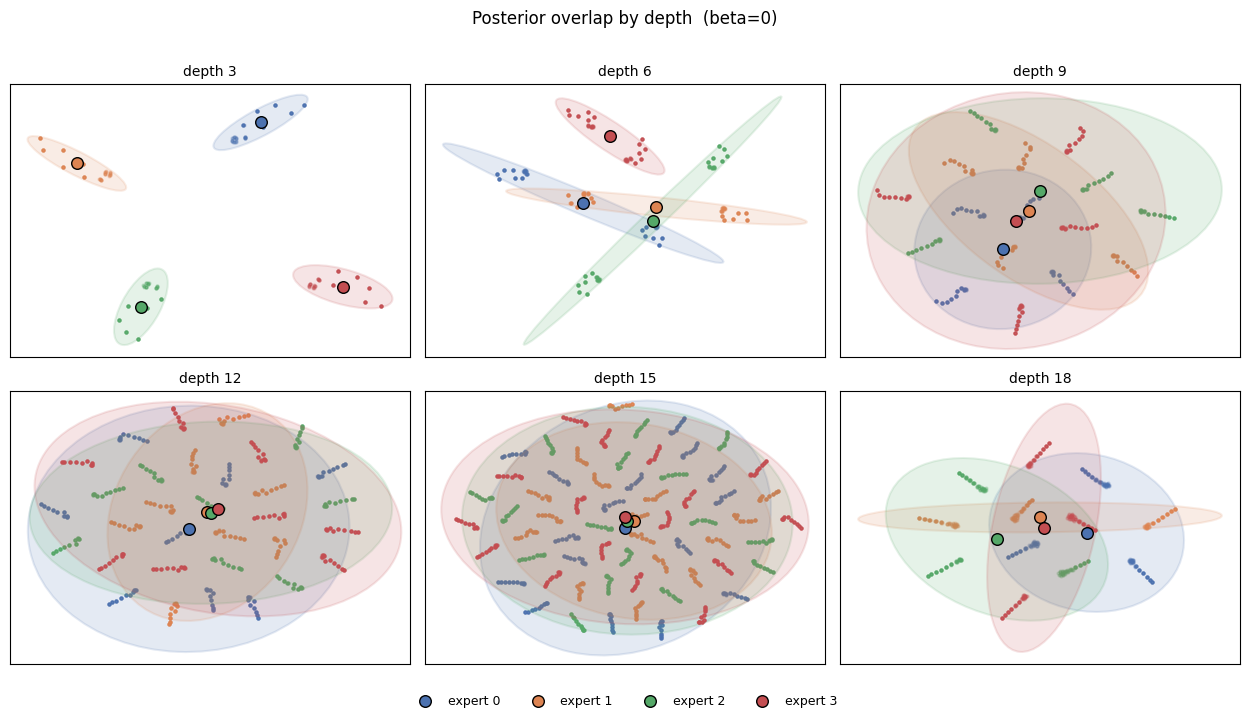

depth  3: between-expert    7.241  posterior sigma    0.171  ratio 42.270
depth  6: between-expert    3.811  posterior sigma    0.165  ratio 23.153
depth  9: between-expert    4.205  posterior sigma    0.142  ratio 29.509
depth 12: between-expert    2.814  posterior sigma    0.103  ratio 27.227
depth 15: between-expert    2.114  posterior sigma    0.121  ratio 17.471
depth 18: between-expert    1.606  posterior sigma    0.171  ratio 9.393


[(3, np.float32(7.2407403), np.float32(0.1712993), np.float32(42.269527)),
 (6, np.float32(3.8107936), np.float32(0.16459394), np.float32(23.152699)),
 (9, np.float32(4.204557), np.float32(0.14248234), np.float32(29.50932)),
 (12, np.float32(2.814476), np.float32(0.103371784), np.float32(27.226734)),
 (15, np.float32(2.1138124), np.float32(0.120989), np.float32(17.471113)),
 (18, np.float32(1.6060448), np.float32(0.17098045), np.float32(9.393148))]

In [23]:
BETA = 0
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA =1e-6 )

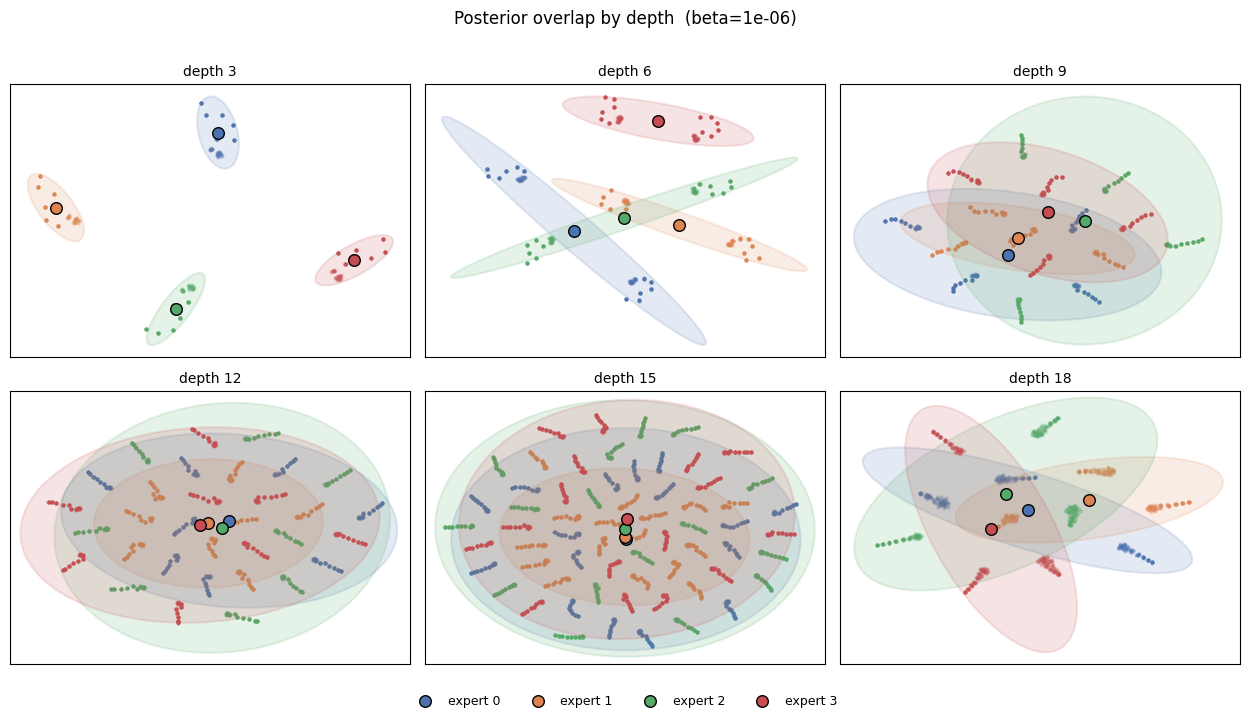

depth  3: between-expert    8.316  posterior sigma    0.630  ratio 13.204
depth  6: between-expert    4.367  posterior sigma    0.586  ratio 7.455
depth  9: between-expert    4.877  posterior sigma    0.564  ratio 8.654
depth 12: between-expert    3.352  posterior sigma    0.585  ratio 5.729
depth 15: between-expert    2.489  posterior sigma    0.548  ratio 4.541
depth 18: between-expert    1.813  posterior sigma    0.577  ratio 3.144


[(3, np.float32(8.315616), np.float32(0.62979954), np.float32(13.203591)),
 (6, np.float32(4.3670983), np.float32(0.5857761), np.float32(7.455235)),
 (9, np.float32(4.877049), np.float32(0.5635662), np.float32(8.653906)),
 (12, np.float32(3.3524523), np.float32(0.5851318), np.float32(5.729397)),
 (15, np.float32(2.4890182), np.float32(0.5481768), np.float32(4.540539)),
 (18, np.float32(1.8134197), np.float32(0.5768081), np.float32(3.1438873))]

In [29]:
BETA = 1e-6
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA = 3e-6 )

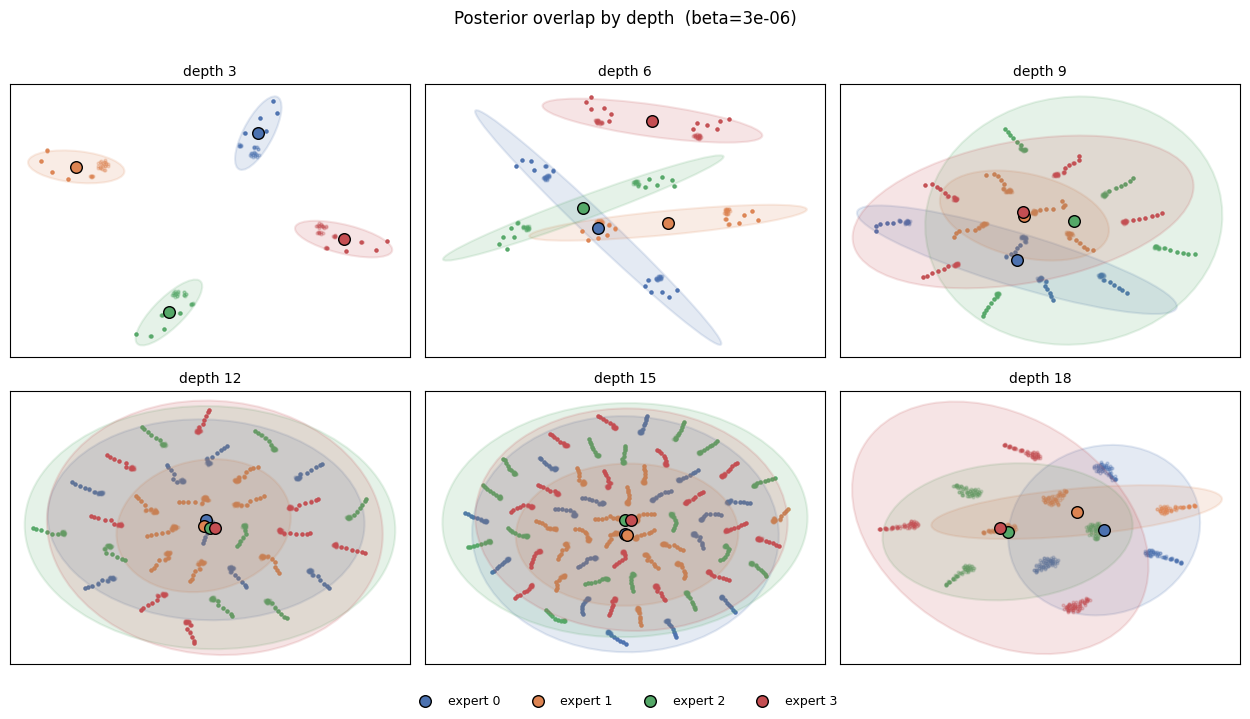

depth  3: between-expert    8.611  posterior sigma    1.112  ratio 7.745
depth  6: between-expert    4.552  posterior sigma    1.049  ratio 4.338
depth  9: between-expert    5.078  posterior sigma    1.031  ratio 4.923
depth 12: between-expert    3.492  posterior sigma    1.097  ratio 3.183
depth 15: between-expert    2.589  posterior sigma    1.015  ratio 2.551
depth 18: between-expert    1.856  posterior sigma    1.020  ratio 1.820


[(3, np.float32(8.610781), np.float32(1.1117358), np.float32(7.745348)),
 (6, np.float32(4.5521584), np.float32(1.0493138), np.float32(4.338224)),
 (9, np.float32(5.077963), np.float32(1.0314391), np.float32(4.9231825)),
 (12, np.float32(3.491676), np.float32(1.0971004), np.float32(3.1826406)),
 (15, np.float32(2.5887692), np.float32(1.0146463), np.float32(2.5514007)),
 (18, np.float32(1.8558012), np.float32(1.0199468), np.float32(1.8195078))]

In [34]:
BETA = 3e-6
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA = 6e-6 )

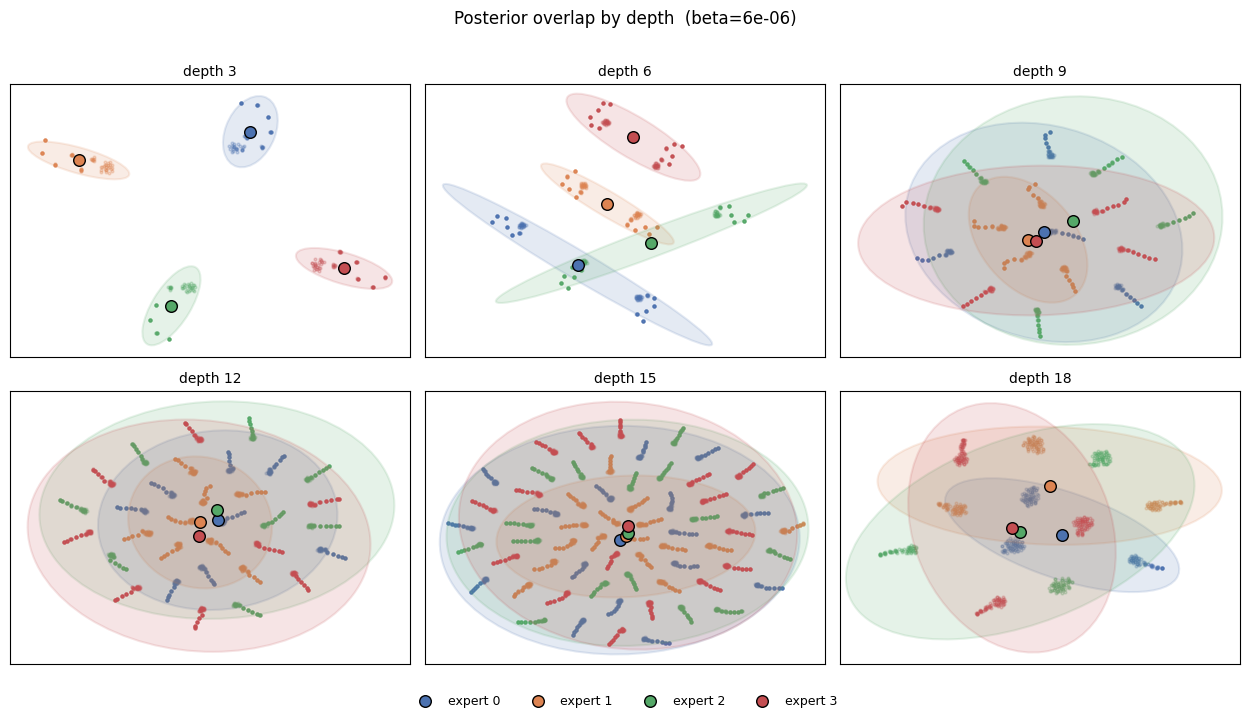

depth  3: between-expert    8.898  posterior sigma    1.649  ratio 5.397
depth  6: between-expert    4.720  posterior sigma    1.563  ratio 3.020
depth  9: between-expert    5.253  posterior sigma    1.542  ratio 3.406
depth 12: between-expert    3.631  posterior sigma    1.652  ratio 2.198
depth 15: between-expert    2.683  posterior sigma    1.520  ratio 1.765
depth 18: between-expert    1.886  posterior sigma    1.523  ratio 1.238


[(3, np.float32(8.897694), np.float32(1.648755), np.float32(5.3966136)),
 (6, np.float32(4.7200856), np.float32(1.5629425), np.float32(3.0199995)),
 (9, np.float32(5.253288), np.float32(1.5423802), np.float32(3.4059615)),
 (12, np.float32(3.630922), np.float32(1.6519133), np.float32(2.1980102)),
 (15, np.float32(2.682803), np.float32(1.5198156), np.float32(1.7652161)),
 (18, np.float32(1.886011), np.float32(1.5233029), np.float32(1.2381064))]

In [35]:
BETA = 6e-6
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA = 9e-6 )

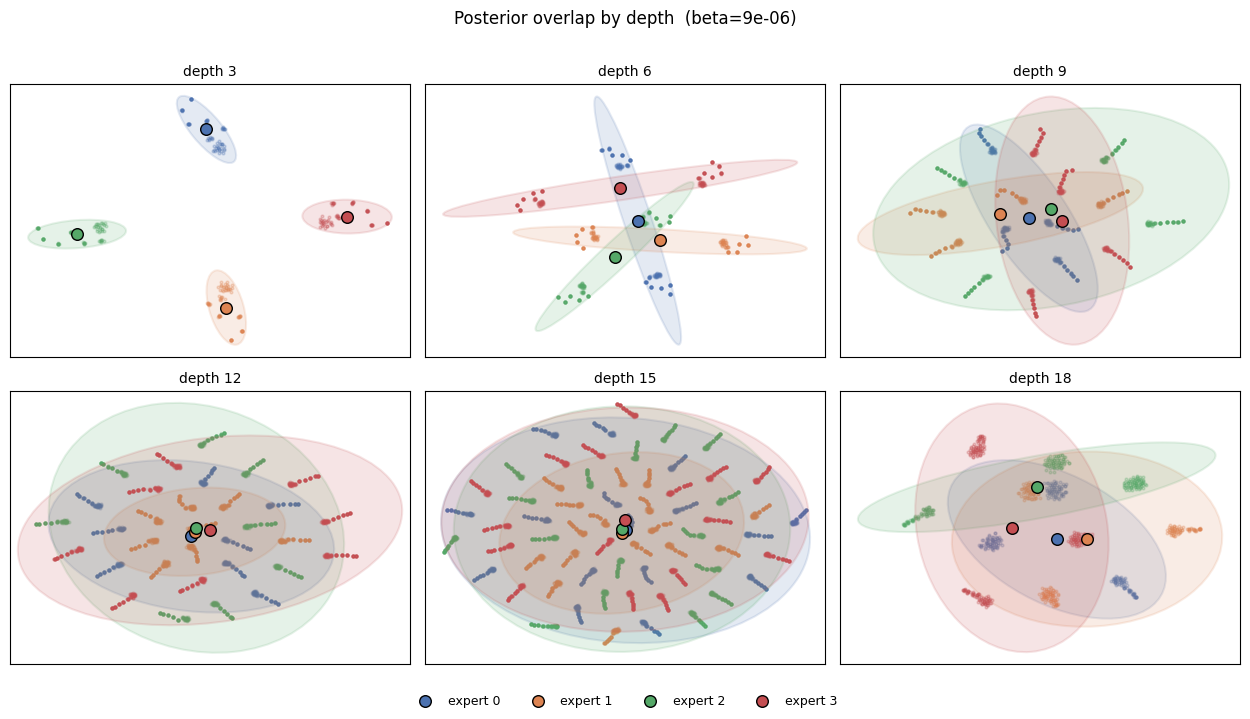

depth  3: between-expert    9.116  posterior sigma    2.097  ratio 4.348
depth  6: between-expert    4.831  posterior sigma    1.989  ratio 2.429
depth  9: between-expert    5.373  posterior sigma    1.966  ratio 2.732
depth 12: between-expert    3.739  posterior sigma    2.121  ratio 1.763
depth 15: between-expert    2.741  posterior sigma    1.938  ratio 1.414
depth 18: between-expert    1.930  posterior sigma    2.050  ratio 0.941


[(3, np.float32(9.116478), np.float32(2.0966508), np.float32(4.3481145)),
 (6, np.float32(4.831294), np.float32(1.9889344), np.float32(2.4290867)),
 (9, np.float32(5.3731246), np.float32(1.9664489), np.float32(2.7323997)),
 (12, np.float32(3.738942), np.float32(2.1209347), np.float32(1.7628746)),
 (15, np.float32(2.7414258), np.float32(1.9383388), np.float32(1.4143171)),
 (18, np.float32(1.9296826), np.float32(2.0504491), np.float32(0.9411024))]

In [36]:
BETA = 9e-6
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA =1e-5 )

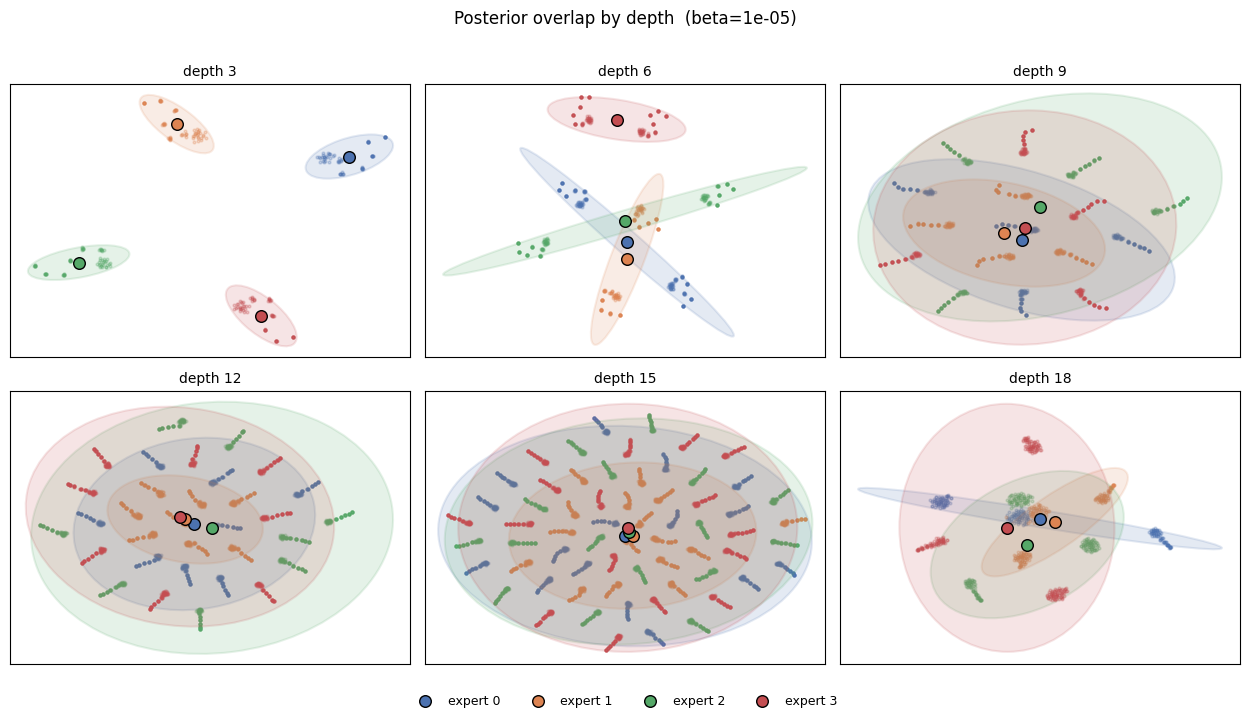

depth  3: between-expert    9.171  posterior sigma    2.233  ratio 4.107
depth  6: between-expert    4.868  posterior sigma    2.120  ratio 2.296
depth  9: between-expert    5.400  posterior sigma    2.092  ratio 2.582
depth 12: between-expert    3.757  posterior sigma    2.257  ratio 1.665
depth 15: between-expert    2.757  posterior sigma    2.063  ratio 1.337
depth 18: between-expert    1.932  posterior sigma    2.235  ratio 0.864


[(3, np.float32(9.171222), np.float32(2.2330694), np.float32(4.1070027)),
 (6, np.float32(4.8680367), np.float32(2.1199777), np.float32(2.296268)),
 (9, np.float32(5.4002132), np.float32(2.091844), np.float32(2.5815563)),
 (12, np.float32(3.7570665), np.float32(2.2565558), np.float32(1.6649562)),
 (15, np.float32(2.7574966), np.float32(2.0627599), np.float32(1.3367996)),
 (18, np.float32(1.9319124), np.float32(2.235046), np.float32(0.8643726))]

In [30]:
BETA = 1e-5
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Latent space analysis (BETA =1e-4 )

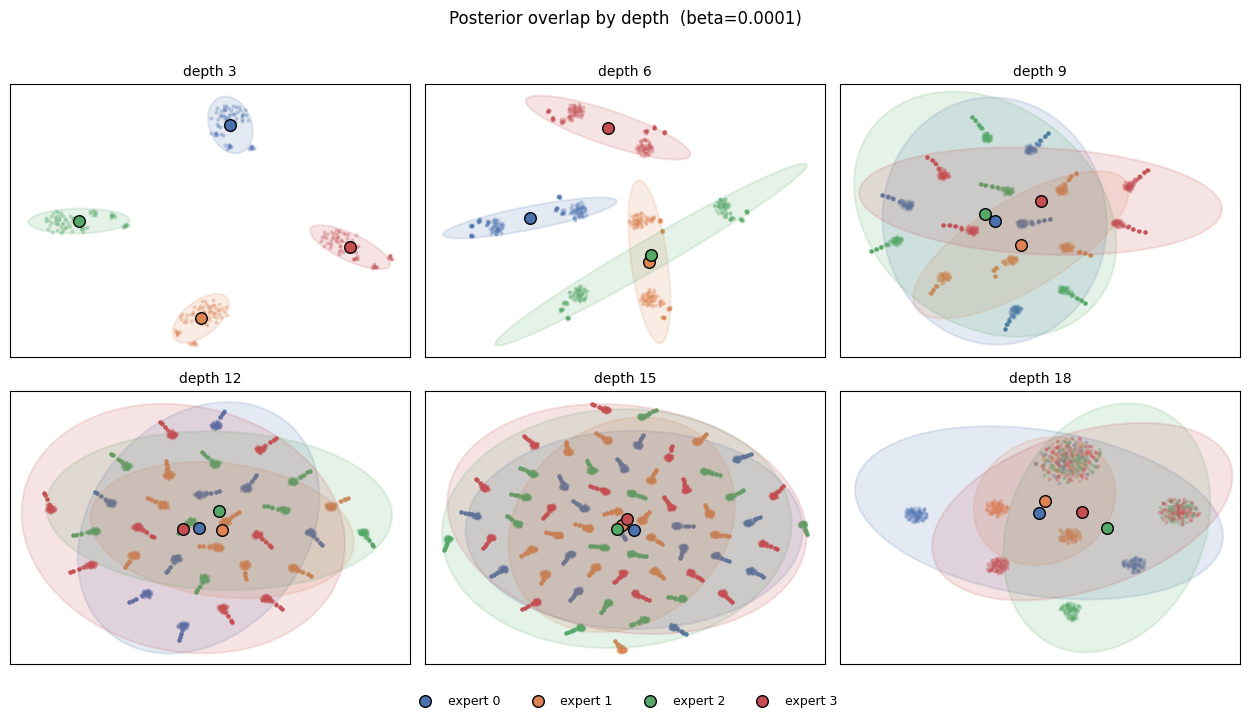

depth  3: between-expert   10.412  posterior sigma    9.185  ratio 1.134
depth  6: between-expert    5.570  posterior sigma    8.670  ratio 0.642
depth  9: between-expert    5.953  posterior sigma    8.275  ratio 0.719
depth 12: between-expert    4.176  posterior sigma    8.972  ratio 0.465
depth 15: between-expert    3.026  posterior sigma    8.071  ratio 0.375
depth 18: between-expert    2.122  posterior sigma   12.082  ratio 0.176


[(3, np.float32(10.41155), np.float32(9.185282), np.float32(1.1335036)),
 (6, np.float32(5.570013), np.float32(8.669611), np.float32(0.64247555)),
 (9, np.float32(5.9533176), np.float32(8.275336), np.float32(0.71940494)),
 (12, np.float32(4.1760488), np.float32(8.972277), np.float32(0.46543914)),
 (15, np.float32(3.0264008), np.float32(8.070709), np.float32(0.37498572)),
 (18, np.float32(2.122004), np.float32(12.081764), np.float32(0.17563693))]

In [31]:
BETA = 1e-4
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])
lat_s, depths_s, midx_s = collect_latents_sampled(tvae_model, ds, n_samples=8)
splits_s = np.array([int(ds.meta_list[m].split_id) for m in midx_s])

plot_overlap_grid(lat_s, depths_s, splits_s, ALL_DEPTHS, tag=f'  (beta={BETA})', savepath=os.path.join(IMG_PATH, f'overlap_beta{BETA}.png'))

posterior_overlap(tvae_model, ds, ALL_DEPTHS)

## Choosing beta

`beta` controls how hard KL pulls the latent codes toward the `N(0,1)` prior. We swept it
from 0 up to 1e-4, fine-tuning from the `r = 1` checkpoint each time so the runs stay
independent.

At `beta = 0` the posterior collapses to sigma 0.17, six times tighter than the prior. That
is not really a VAE, it is a deterministic autoencoder with an unused variance head. KL
pushes sigma back up rather than down, which is the opposite of the posterior collapse the
paper warns about.

The tradeoff is that a wider posterior blurs the experts together. `posterior_overlap`
measures this as between-expert distance divided by the encoder's own uncertainty. Below 1
means two experts overlap within their own spread, so there is nothing distinct left to
merge.

| beta | val recon | posterior sigma | overlap ratio at `fc.weight` |
|---|---|---|---|
| 0 | 0.00198 | 0.17 | 9.39 |
| 1e-6 | 0.00176 | 0.57 | 3.16 |
| **3e-6** | **0.00176** | **1.11** | **1.82** |
| 6e-6 | 0.00179 | 1.65 | 1.24 |
| 9e-6 | 0.00181 | 2.10 | 0.94 |
| 1e-5 | 0.00182 | 2.15 | 0.86 |
| 1e-4 | 0.00242 | 9.00 | 0.18 |

We use **`beta = 3e-6`**. It ties for the best val recon, its posterior sigma lands at 1.11
which is essentially the prior, and expert separation at the classifier head stays at 1.82.
Above 9e-6 the ratio drops below 1 and the experts stop being distinguishable.

Two other things pointed the same way. Higher beta inflates the reconstruction baseline:
passing an expert through the VAE lifts its other-group accuracy from 6.25% to 9.95% at
`beta = 0` but to 13.41% at `beta = 1e-4`, purely from smoothing. And the tail degrades: the
outlier weight at index 1249 of `layer1.2.conv2` reconstructs to 1% error at `beta = 0` and
10% error at `beta = 1e-4`.

In [12]:
BETA = 3e-6
tvae_model.load_state_dict(torch.load(f'./res_models/tvae_r1_beta{BETA}.pt', weights_only=True)['state_dict'])

<All keys matched successfully>

## Reconstruction check (BETA = 3e-6)

In [12]:
'''reconstruction baseline for the chosen beta, this is the number the merge must beat'''
ds_one = ResZoo(root_dir=zoo_dir, model_ids=[MODEL_ID])
loader_one = DataLoader(ds_one, batch_size=64, shuffle=False)

ck = torch.load('res_models/expert3_seed1246/ep040.pt', map_location='cpu')
sd_hat = reconstruct_model(tvae_model, loader_one, ds_one, ck['state_dict'])

recal_subset = torch.utils.data.Subset(train_dataset_cifar, zoo_train_feed[EXPERT_ID])
recal_loader = DataLoader(recal_subset, batch_size=128, shuffle=True, num_workers=2)

evaluate_reconstruction(sd_hat, ck['state_dict'], EXPERT_ID, recal_loader, full_test_loader)

                   own   other     all
original         83.60    6.25   21.72
reconstructed    83.45    9.34   24.16
delta            -0.15    3.09    2.44

  worst rel err  layer3.1.conv1.weight      0.1094
  worst rel err  layer3.0.conv2.weight      0.1077
  worst rel err  layer2.1.conv2.weight      0.1032
  worst rel err  layer2.0.conv2.weight      0.1012
  worst rel err  layer3.1.conv2.weight      0.0955

  index 1249 of layer1.2.conv2: original -0.6102  reconstructed -0.5705


2.4400000000000013

## Self-Interpolation

In [13]:
@torch.no_grad()
def self_interpolation(model, loader, lam, seed=SEED):
    '''interpolate between two posterior samples of the SAME model. sample explicitly, reparameterize returns mu in eval mode'''
    model.eval()
    g = torch.Generator(device=device).manual_seed(seed)

    outs, depths, stages = [], [], []
    for batch in loader:
        chunks = batch['chunks'].to(device, non_blocking=True)
        depth = batch['depth'].to(device, non_blocking=True)
        stage = batch['stage'].to(device, non_blocking=True)

        mu, logvar = model.encode(chunks, depth, stage)
        std = torch.exp(0.5 * logvar)
        z1 = mu + std * torch.randn(std.shape, generator=g, device=device)
        z2 = mu + std * torch.randn(std.shape, generator=g, device=device)

        z = z1 * lam + z2 * (1 - lam)
        outs.append(model.decode(z, depth, stage).cpu())
        depths.append(depth.cpu())
        stages.append(stage.cpu())

    return torch.concat(outs, dim=0)

In [ ]:
from reconstruction import (interp_to_state_dict, eval_state_dict)

EXPERT_ID = 3
MODEL_ID = 'split3_seed1246_ep40'

ds_one = ResZoo(root_dir=zoo_dir, model_ids=[MODEL_ID])
loader_one = DataLoader(ds_one, batch_size=64, shuffle=False)
ck = torch.load('res_models/expert3_seed1246/ep040.pt', map_location='cpu')

recal_subset = torch.utils.data.Subset(train_dataset_cifar, zoo_train_feed[EXPERT_ID])
recal_loader = DataLoader(recal_subset, batch_size=128, shuffle=True, num_workers=2)

In [37]:
lambdas = torch.linspace(0.0, 1.0, 11)
rows = []

In [38]:
for lam in tqdm(lambdas):
    '''same seed every time so the two endpoints stay fixed across the sweep'''
    out = self_interpolation(tvae_model, loader_one, lam.item(), seed=0)
    sd = interp_to_state_dict(out, ds_one, ck['state_dict'])
    own, other, all_ = eval_state_dict(sd, EXPERT_ID, recal_loader, full_test_loader)
    rows.append((lam.item(), own, other, all_))
    print(f'lam {lam:.2f}  own {own:6.2f}  other {other:6.2f}  all {all_:6.2f}')

  9%|█████████████                                                                                                                                  | 1/11 [00:04<00:46,  4.62s/it]

lam 0.00  own  83.75  other   9.10  all  24.03


 18%|██████████████████████████                                                                                                                     | 2/11 [00:09<00:41,  4.62s/it]

lam 0.10  own  83.55  other   8.71  all  23.68


 27%|███████████████████████████████████████                                                                                                        | 3/11 [00:13<00:36,  4.62s/it]

...

lam 0.80  own  83.65  other   9.07  all  23.99


 91%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████             | 10/11 [00:46<00:04,  4.60s/it]

lam 0.90  own  84.05  other   9.39  all  24.32


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 11/11 [00:50<00:00,  4.61s/it]

lam 1.00  own  84.00  other   9.19  all  24.15


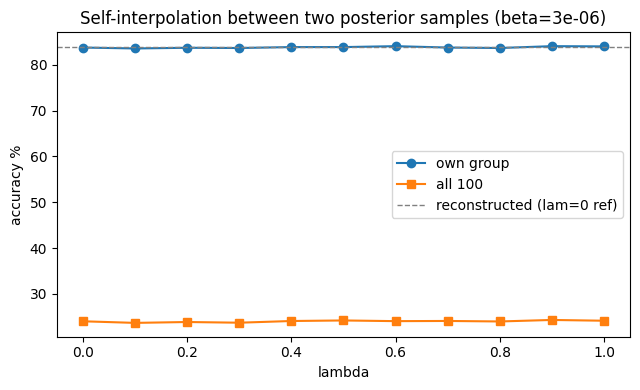

In [40]:
import matplotlib.pyplot as plt
lams = [r[0] for r in rows]
fig, ax = plt.subplots(figsize=(6.5, 4))
ax.plot(lams, [r[1] for r in rows], marker='o', label='own group')
ax.plot(lams, [r[3] for r in rows], marker='s', label='all 100')
ax.axhline(83.85, ls='--', c='gray', lw=1, label='reconstructed (lam=0 ref)')
ax.set_xlabel('lambda'); ax.set_ylabel('accuracy %')
ax.set_title(f'Self-interpolation between two posterior samples (beta={BETA})')
ax.legend(); fig.tight_layout(); plt.show()

In [16]:
from sklearn.decomposition import IncrementalPCA


def fit_pca_baseline(train_dataset, r, batch_size=1024):
    '''fit incremental pca on the same chunks the vae trained on.
    chunks are already normalized and companded so this is the fair comparison'''
    X = np.concatenate([c for c in train_dataset.chunks_list])
    k = max(1, int(round(train_dataset.chunk_size / r)))
    ipca = IncrementalPCA(n_components=k, batch_size=batch_size)
    ipca.fit(X)
    print(f'r={r}  k={k}  explained variance {ipca.explained_variance_ratio_.sum():.4f}  '
          f'fit on {X.shape[0]} chunks')
    return ipca


def pca_reconstruct(ipca, dataset):
    '''project one model down to k components and back'''
    meta = dataset.meta_list[0]
    X = dataset.chunks_list[0]
    rec = ipca.inverse_transform(ipca.transform(X)).astype(np.float32)
    rel = np.linalg.norm(X - rec) / np.linalg.norm(X)
    return rec, rel

In [17]:
'''pca baseline at matched compression ratios, this is the paper's section 5.3'''
EXPERT_ID = 3
ck = torch.load('res_models/expert3_seed1246/ep040.pt', map_location='cpu')

rows = []
for r in [1.6, 2.0, 4.0]:
    ipca = fit_pca_baseline(train_dataset, r)
    rec, rel = pca_reconstruct(ipca, ds_one)
    sd = C.reconstruct_state_dict(rec, ds_one.meta_list[0], ck['state_dict'])
    own, other, all_ = eval_state_dict(sd, EXPERT_ID, recal_loader, full_test_loader)
    rows.append((r, rel, own, other, all_))
    print(f'  chunk rel err {rel:.4f}   own {own:6.2f}  other {other:6.2f}  all {all_:6.2f}')

print()
print(f'{"method":<18}{"r":>6}{"own":>9}{"other":>9}{"all":>9}')
print(f'{"original":<18}{"-":>6}{83.60:>9.2f}{6.25:>9.2f}{21.72:>9.2f}')
print(f'{"VAE":<18}{1.0:>6}{83.85:>9.2f}{9.50:>9.2f}{24.37:>9.2f}')
for r, rel, own, other, all_ in rows:
    print(f'{"PCA":<18}{r:>6}{own:>9.2f}{other:>9.2f}{all_:>9.2f}')

r=1.6  k=90  explained variance 0.8959  fit on 51408 chunks
  chunk rel err 0.3224   own  68.20  other   1.34  all  14.71
r=2.0  k=72  explained variance 0.8248  fit on 51408 chunks
  chunk rel err 0.4181   own  54.70  other   0.25  all  11.14
r=4.0  k=36  explained variance 0.5918  fit on 51408 chunks
  chunk rel err 0.6369   own  12.05  other   0.00  all   2.41

method                 r      own    other      all
original               -    83.60     6.25    21.72
VAE                  1.0    83.85     9.50    24.37
PCA                  1.6    68.20     1.34    14.71
PCA                  2.0    54.70     0.25    11.14
PCA                  4.0    12.05     0.00     2.41


In [9]:
def build_raw_chunks(dataset):
    '''pull the stored chunks straight out of the dataset, no encoder involved.
    same [N, 16, 144] shape as collect_latents so the plotting and metric
    functions work unchanged'''
    raw, depths, midx = [], [], []
    for m, start in dataset.index:
        T = dataset.tokens_per_seq
        raw.append(dataset.chunks_list[m][start:start + T])
        depths.append(int(dataset.row_layer[m][start]))
        midx.append(m)

    raw = np.stack(raw)
    depths = np.array(depths)
    midx = np.array(midx)
    splits = np.array([int(dataset.meta_list[m].split_id) for m in midx])
    return raw, depths, splits


def relative_separation(X_all, depths, splits, depth_list, label='', verbose=True):
    '''between expert mean distance as a fraction of the mean norm.
    scale free, so raw chunks and latents can be compared directly'''
    rows = []
    for d in depth_list:
        sel = np.where(depths == d)[0]
        lbl = splits[sel]
        keep = lbl != BACKBONE_LABEL
        sel, lbl = sel[keep], lbl[keep]
        if len(sel) < 2:
            continue
        X = X_all[sel].reshape(len(sel), -1)
        experts = sorted(set(lbl.tolist()))
        means = {sp: X[lbl == sp].mean(0) for sp in experts}
        ds = [np.linalg.norm(means[a] - means[b])
              for i, a in enumerate(experts) for b in experts[i + 1:]]
        nrm = np.mean([np.linalg.norm(means[sp]) for sp in experts])
        rel = np.mean(ds) / nrm
        rows.append((d, np.mean(ds), nrm, rel))
        if verbose:
            print(f'{label}depth {d:>2}: between {np.mean(ds):8.4f}  '
                  f'norm {nrm:8.4f}  relative {rel:.5f}')
    return rows

raw chunks (4284, 16, 144)  experts [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]


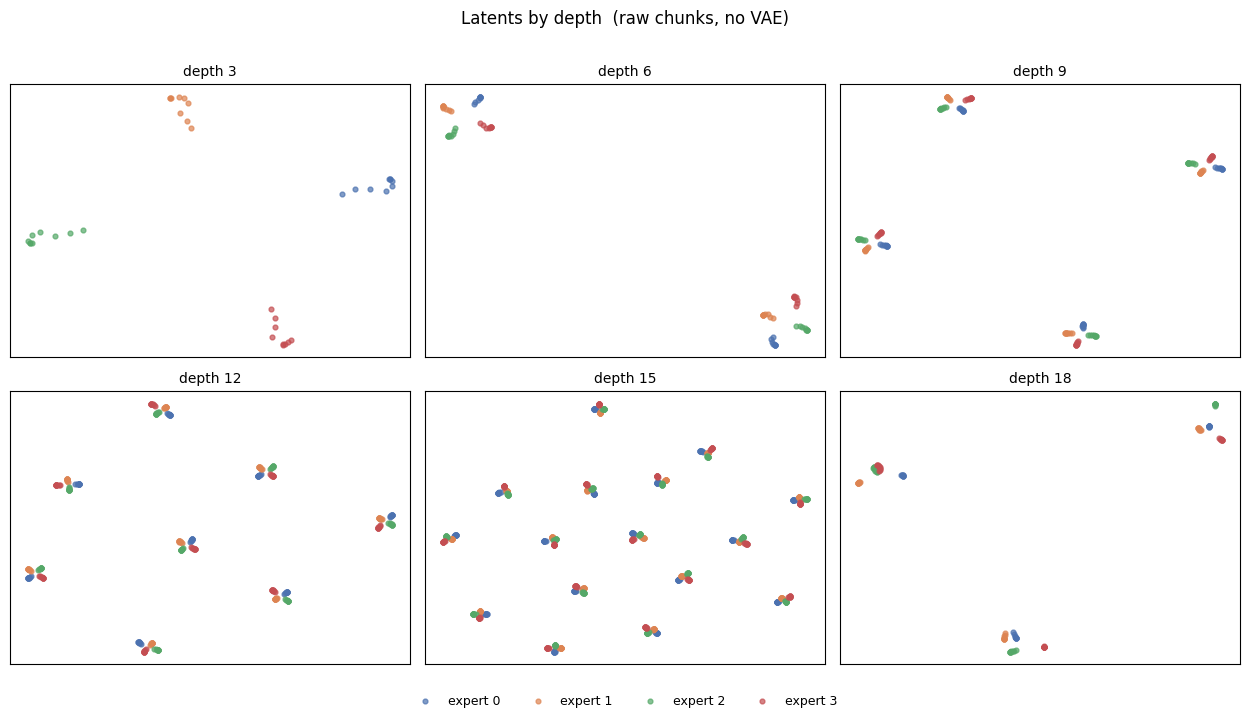


depth  3: within    2.193  between    6.847  ratio 3.122
depth  6: within   21.314  between   21.941  ratio 1.029
depth  9: within   33.094  between   33.663  ratio 1.017
depth 12: within   36.976  between   37.141  ratio 1.004
depth 15: within   39.448  between   39.577  ratio 1.003
depth 18: within   26.842  between   26.822  ratio 0.999


[(3, np.float32(2.193151), np.float32(6.847191), np.float32(3.1220791)),
 (6, np.float32(21.313763), np.float32(21.941431), np.float32(1.029449)),
 (9, np.float32(33.09379), np.float32(33.663338), np.float32(1.0172101)),
 (12, np.float32(36.97619), np.float32(37.14096), np.float32(1.0044562)),
 (15, np.float32(39.44764), np.float32(39.576767), np.float32(1.0032734)),
 (18, np.float32(26.841763), np.float32(26.822243), np.float32(0.99927276))]

In [19]:
'''raw chunks, before the encoder ever sees them'''
ds = ResZoo(root_dir=zoo_dir, model_ids=training_set + validation_set)
raw, depths_r, splits_r = build_raw_chunks(ds)
print(f'raw chunks {raw.shape}  experts {sorted(set(splits_r))}')

plot_depth_grid(raw, depths_r, splits_r, ALL_DEPTHS, n_cols=3,
                tag='  (raw chunks, no VAE)',
                savepath=os.path.join(IMG_PATH, 'raw_grid.png'))

print()
expert_separation(raw, depths_r, splits_r, ALL_DEPTHS)

## Retraining on several initialisations

The autoencoder above reconstructs an in-distribution expert at $0.10$ relative error and a
model from an unseen initialisation at $0.37$, losing 26 to 30 accuracy points. That makes
the permutation test unreadable.

Here we add the two extra lineages to the training set and repeat the same two stage
curriculum. `indep_0` and `indep_1` are still never seen, so they stay usable as merge
subjects. Everything is written to new paths so the original results are not overwritten.

In [10]:
'''the extra lineages were skipped by the expert split parser, add them by hand'''
extra_ids = sorted(d for d in os.listdir(zoo_dir)
                   if d.startswith('indeptrain'))
print(f'{len(extra_ids)} extra checkpoints:', extra_ids[:4], '...')

training_set_v2 = training_set + extra_ids

'''nothing that gets merged may appear in training'''
assert set(training_set_v2).isdisjoint(validation_set)
assert set(training_set_v2).isdisjoint(merge_set)
assert not any(i.startswith('indep_') for i in training_set_v2)

train_dataset_v2 = ResZoo(root_dir=zoo_dir, model_ids=training_set_v2)
train_loader_v2 = DataLoader(train_dataset_v2, batch_size=64, shuffle=True,
                             num_workers=2, pin_memory=True, drop_last=True)

print(f'v1 {len(training_set)} models / {len(train_dataset)} sequences')
print(f'v2 {len(training_set_v2)} models / {len(train_dataset_v2)} sequences')

20 extra checkpoints: ['indeptrainA_ep020', 'indeptrainA_ep040', 'indeptrainA_ep060', 'indeptrainA_ep080'] ...
v1 27 models / 3213 sequences
v2 47 models / 5593 sequences


In [11]:
'''stage one, deterministic autoencoder on the expanded zoo'''
tvae_v2 = TVAE(input_dim=144, model_dim=256, latent_dim=144).to(device)
tvae_v2_path = './res_models/tvae_v2_r1.pt'

if not os.path.exists(tvae_v2_path):
    train_tvae(tvae_v2, train_loader_v2, validation_loader,
               lr=1e-4, EPOCHS=200, BETA=0.0, output_path=tvae_v2_path)

tvae_v2.load_state_dict(torch.load(tvae_v2_path, weights_only=True)['state_dict'])
tvae_v2 = tvae_v2.to(device)

epoch   1/200  train recon 0.39752  val recon 0.36091  kl 75.17  lr 1.00e-04
epoch   5/200  train recon 0.07608  val recon 0.06446  kl 369.72  lr 9.98e-05
epoch  10/200  train recon 0.03187  val recon 0.02821  kl 517.57  lr 9.94e-05
epoch  15/200  train recon 0.01883  val recon 0.01697  kl 591.93  lr 9.86e-05
epoch  20/200  train recon 0.01267  val recon 0.01043  kl 633.21  lr 9.76e-05
epoch  25/200  train recon 0.00952  val recon 0.00751  kl 659.27  lr 9.62e-05
epoch  30/200  train recon 0.00698  val recon 0.00625  kl 688.04  lr 9.46e-05
epoch  35/200  train recon 0.00526  val recon 0.00389  kl 710.20  lr 9.26e-05
epoch  40/200  train recon 0.00406  val recon 0.00354  kl 735.08  lr 9.05e-05
epoch  45/200  train recon 0.00327  val recon 0.00234  kl 753.12  lr 8.80e-05
epoch  50/200  train recon 0.00248  val recon 0.00170  kl 778.09  lr 8.54e-05
epoch  55/200  train recon 0.00210  val recon 0.00139  kl 795.79  lr 8.25e-05
epoch  60/200  train recon 0.00178  val recon 0.00115  kl 815.06 

In [15]:
'''stage two, same beta we selected before'''
BETA_V2 = 3e-5
tvae_v2_beta_path = f'./res_models/tvae_v2_r1_beta{BETA_V2}.pt'

if not os.path.exists(tvae_v2_beta_path):
    train_tvae(tvae_v2, train_loader_v2, validation_loader,
               lr=1e-4, EPOCHS=50, BETA=BETA_V2, output_path=tvae_v2_beta_path)

tvae_v2.load_state_dict(torch.load(tvae_v2_beta_path, weights_only=True)['state_dict'])
tvae_v2 = tvae_v2.to(device)

In [18]:
'''the check that decides whether this worked. v1 gave 0.37 mean relative error
on these models and lost 26 to 30 accuracy points'''
from reconstruction import recalibrate_bn

recal_all = DataLoader(train_dataset_cifar, batch_size=128, shuffle=True, num_workers=2)

@torch.no_grad()
def _range_acc(model, loader, lo, hi):
    model.eval()
    c = n = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        pred = model(images).argmax(1)
        m = (labels >= lo) & (labels < hi)
        c += (pred[m] == labels[m]).sum().item(); n += m.sum().item()
    return 100.0 * c / max(n, 1)

for tag, model_vae in [('v1 (one lineage)', tvae_model), ('v2 (three lineages)', tvae_v2)]:
    print(f'--- {tag} ---')
    for name, (lo, hi) in [('indep_0', (0, 50)), ('indep_1', (50, 100))]:
        ds = ResZoo(root_dir='./zoo_independent', model_ids=[name])
        loader = DataLoader(ds, batch_size=64, shuffle=False)
        ck = torch.load(f'res_models_independent/{name}.pt', map_location='cpu')

        sd_hat = reconstruct_model(model_vae, loader, ds, ck['state_dict'])

        m_ref = resnet20(num_classes=100).to(device)
        m_ref.load_state_dict(ck['state_dict'], strict=True); m_ref.eval()
        acc_ref = _range_acc(m_ref, full_test_loader, lo, hi)

        m_hat = resnet20(num_classes=100).to(device)
        m_hat.load_state_dict(sd_hat, strict=True)
        recalibrate_bn(m_hat, recal_all)
        acc_hat = _range_acc(m_hat, full_test_loader, lo, hi)

        errs = [((ck['state_dict'][k].float() - sd_hat[k].float().cpu()).norm()
                 / ck['state_dict'][k].float().norm()).item()
                for k in sd_hat
                if k in ck['state_dict'] and ck['state_dict'][k].dtype == torch.float32
                and ck['state_dict'][k].dim() >= 2]
        print(f'  {name}  own {acc_ref:6.2f} -> {acc_hat:6.2f}  '
              f'(delta {acc_hat - acc_ref:+6.2f})  mean rel err {sum(errs)/len(errs):.4f}')

--- v1 (one lineage) ---
  indep_0  own  75.36 ->  47.70  (delta -27.66)  mean rel err 0.3820
  indep_1  own  76.06 ->  44.38  (delta -31.68)  mean rel err 0.3804
--- v2 (three lineages) ---
  indep_0  own  75.36 ->  72.22  (delta  -3.14)  mean rel err 0.1025
  indep_1  own  76.06 ->  72.60  (delta  -3.46)  mean rel err 0.1079
